# NYC Construction Permit Approval Duration
## Feature Engineering and Cleaning

This notebook prepares the dataset for modeling. Key steps include converting 
date columns to the appropriate type, computing the response variable 
(`approval_duration`), encoding categorical predictors, and removing records 
that cannot be used for modeling.

#### Data Load

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sodapy import Socrata

client = Socrata("data.cityofnewyork.us", None)
results = client.get("ipu4-2q9a", limit=100000)
df = pd.DataFrame.from_records(results)

#### Response Variable: Approval Duration

The response variable is the number of days between `filing_date` and 
`issuance_date`. We first convert both columns from strings to datetime objects, 
then compute the difference in days.

In [2]:
df['filing_date'] = pd.to_datetime(df['filing_date'])
df['issuance_date'] = pd.to_datetime(df['issuance_date'])

df['approval_duration'] = (df['issuance_date'] - df['filing_date']).dt.days

print(df['approval_duration'].describe())

count    98445.000000
mean         7.378790
std        105.914907
min        -98.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       7063.000000
Name: approval_duration, dtype: float64


#### Duration Distribution

Examine the distribution of `approval_duration` to identify outliers and 
assess the feasibility of predicting duration across all permit types.

In [3]:
print("Zero or same-day approvals:", (df['approval_duration'] == 0).sum())
print("Negative durations:", (df['approval_duration'] < 0).sum())
print("Over 365 days:", (df['approval_duration'] > 365).sum())
print("1-365 days:", ((df['approval_duration'] > 0) & (df['approval_duration'] <= 365)).sum())

Zero or same-day approvals: 87810
Negative durations: 1
Over 365 days: 356
1-365 days: 10278


#### Scoping Decision

The majority of records (89%) show same-day approval, likely corresponding to 
self-certified or pre-approved permit types where duration is not meaningfully 
variable. To focus the analysis on permits where approval time is genuinely 
uncertain, we restrict the dataset to records with an approval duration between 
1 and 365 days. Negative durations are treated as data entry errors and excluded. 
Records exceeding 365 days are excluded as extreme outliers.

This yields a focused modeling dataset of permits where duration is both 
meaningful and bounded.

In [4]:
df_model = df[(df['approval_duration'] > 0) & (df['approval_duration'] <= 365)].copy()

print(df_model.shape)
print(df_model['approval_duration'].describe())

(10278, 60)
count    10278.000000
mean        28.389278
std         52.219443
min          1.000000
25%          4.000000
50%         10.000000
75%         26.000000
max        365.000000
Name: approval_duration, dtype: float64


#### Approval Duration Distribution

Following the scoping decision, we examine the distribution of approval duration 
across the modeling dataset to understand the shape and spread of the response variable.

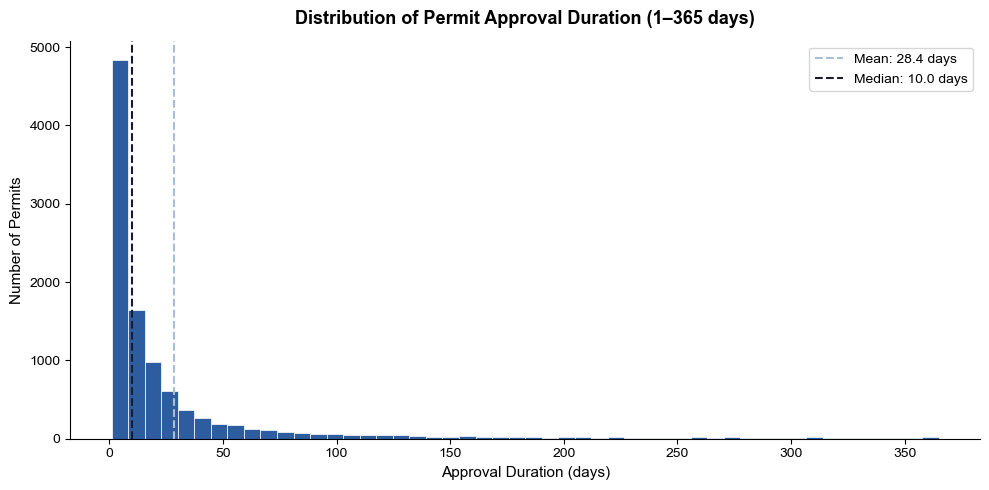

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_model['approval_duration'], bins=50, color='#2E5D9F', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Approval Duration (days)', fontsize=11)
ax.set_ylabel('Number of Permits', fontsize=11)
ax.set_title('Distribution of Permit Approval Duration (1–365 days)', fontsize=13, fontweight='bold', pad=12)
ax.axvline(df_model['approval_duration'].mean(), color='#A8BDD6', linestyle='--', linewidth=1.5, label=f"Mean: {df_model['approval_duration'].mean():.1f} days")
ax.axvline(df_model['approval_duration'].median(), color='#1A1A2E', linestyle='--', linewidth=1.5, label=f"Median: {df_model['approval_duration'].median():.1f} days")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('approval_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Feature Selection and Encoding

Retain the variables most relevant to predicting approval duration and encode 
categorical predictors. Missing values in `work_type` and `residential` are 
retained as a distinct category given their structural nature identified in 
Notebook 1.

In [5]:
features = ['job_type', 'work_type', 'borough', 'bldg_type', 
            'permit_type', 'residential', 'approval_duration']

df_model = df_model[features].copy()

df_model['work_type'] = df_model['work_type'].fillna('UNKNOWN')
df_model['residential'] = df_model['residential'].fillna('UNKNOWN')
df_model['bldg_type'] = df_model['bldg_type'].fillna('UNKNOWN')

df_encoded = pd.get_dummies(df_model, 
                            columns=['job_type', 'work_type', 'borough', 
                                     'bldg_type', 'permit_type', 'residential'],
                            drop_first=True)

print(df_encoded.shape)

(10278, 31)


#### Save Cleaned Dataset

The cleaned, encoded dataset is saved as a CSV for use in subsequent modeling notebooks.

In [6]:
df_encoded.to_csv('permit_model_data.csv', index=False)
print("Saved:", df_encoded.shape)

Saved: (10278, 31)


#### Summary

The raw dataset was filtered to 10,278 permits with approval durations between 
1 and 365 days. Categorical variables were encoded using one-hot encoding, 
yielding a final dataset of 30 predictors and one response variable 
(`approval_duration`). The cleaned dataset is saved to `permit_model_data.csv` 
for use in subsequent modeling notebooks.